# XAI Robustness Study: EUR/USD Next-Day Direction Model

**Research question:** How consistent and robust are explanations for an EUR/USD next-day direction model when using SHAP, Permutation Feature Importance (PFI), and Feature Ablation?

In [55]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
import shap
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.inspection import permutation_importance
from sklearn.metrics import roc_auc_score, accuracy_score
from scipy.stats import spearmanr

np.random.seed(42)
matplotlib.rcParams['figure.dpi'] = 120

---
## Classes

All logic is organised into classes so each pipeline step is self-contained and easy to follow.

In [56]:
class EURUSDDataset:

    FEATURES = [
        'close_return', 'open_close_range', 'high_low_spread',
        'ma3_return', 'ma5_return', 'lag1_return', 'lag2_return', 'lag3_return',
    ]

    def __init__(self, filepath):
        self.filepath = filepath
        self.df = None
        self.X = None
        self.y = None

    def load(self):
        # reverse to chronological order, the CSV is newest-first
        df = pd.read_csv(self.filepath).iloc[::-1].reset_index(drop=True)
        df = df.rename(columns={'Price': 'Close'})[['Date', 'Open', 'High', 'Low', 'Close']].copy()
        df['Date'] = pd.to_datetime(df['Date'], format='%d-%m-%Y')
        self.df = df
        print(f"Loaded {len(df)} rows  |  {df['Date'].min().date()} to {df['Date'].max().date()}")

    def build_features(self):
        # build features and create the up/down target
        df = self.df
        df['close_return'] = df['Close'].pct_change()
        df['open_close_range'] = (df['Close'] - df['Open']) / df['Open']
        df['high_low_spread'] = (df['High'] - df['Low']) / df['Close']
        df['ma3_return'] = df['close_return'].rolling(3).mean()
        df['ma5_return'] = df['close_return'].rolling(5).mean()
        df['lag1_return'] = df['close_return'].shift(1)
        df['lag2_return'] = df['close_return'].shift(2)
        df['lag3_return'] = df['close_return'].shift(3)
        df['direction'] = (df['Close'].shift(-1) > df['Close']).astype(int)
        self.df = df.dropna().reset_index(drop=True)
        self.X = self.df[self.FEATURES].values
        self.y = self.df['direction'].values
        print(f"Dataset after cleaning: {len(self.df)} rows")
        print(f"Class balance  Up: {self.y.mean():.1%}, Down: {1 - self.y.mean():.1%}")

In [57]:
class DirectionModel:

    def __init__(self, test_fraction=0.2):
        self.test_fraction = test_fraction
        self.scaler = StandardScaler()
        self.classifier = LogisticRegression(max_iter=1000, random_state=42)
        self.X_train_scaled = None
        self.X_test_scaled = None
        self.y_train = None
        self.y_test = None
        self.y_pred_proba = None
        self.accuracy = None
        self.auc = None

    def fit(self, X, y):
        # chronological split - no shuffle to avoid data leakage
        split_idx = int(len(X) * (1 - self.test_fraction))
        self.y_train, self.y_test = y[:split_idx], y[split_idx:]
        self.X_train_scaled = self.scaler.fit_transform(X[:split_idx])
        self.X_test_scaled = self.scaler.transform(X[split_idx:])
        self.classifier.fit(self.X_train_scaled, self.y_train)
        # evaluate on the test set
        y_pred = self.classifier.predict(self.X_test_scaled)
        self.y_pred_proba = self.classifier.predict_proba(self.X_test_scaled)[:, 1]
        self.accuracy = accuracy_score(self.y_test, y_pred)
        self.auc = roc_auc_score(self.y_test, self.y_pred_proba)
        print(f"Test Accuracy: {self.accuracy:.4f}")
        print(f"Test AUC-ROC: {self.auc:.4f}")
        print(f"Train size: {split_idx}, Test size: {len(X) - split_idx}")

In [58]:
class SHAPExplainer:

    def __init__(self, feature_names):
        self.feature_names = feature_names
        self._explainer = None
        self._shap_values = None
        self.importance = None
        self.ranking = None

    def fit_explain(self, classifier, X_train_scaled, X_test_scaled):
        # use LinearExplainer for exact values on a linear model
        self._explainer = shap.LinearExplainer(classifier, X_train_scaled, feature_names=self.feature_names)
        self._shap_values = self._explainer(X_test_scaled)
        self.importance = np.abs(self._shap_values.values).mean(axis=0)
        self.ranking = pd.Series(self.importance, index=self.feature_names).sort_values(ascending=False)
        print("SHAP global feature importance:")
        print(self.ranking.to_string())

    def compute_importance_for(self, X):
        # mean |SHAP| per feature, used in robustness loop
        return np.abs(self._explainer(X).values).mean(axis=0)

    def plot_bar(self):
        shap.plots.bar(self._shap_values, max_display=8, show=True)
        plt.tight_layout(); plt.show()

    def plot_beeswarm(self):
        shap.plots.beeswarm(self._shap_values, max_display=8, show=True)
        plt.tight_layout(); plt.show()

    def plot_waterfall(self, instance_idx, label, probability):
        print(f"Instance {instance_idx}: predicted {label} (prob={probability:.3f})")
        shap.plots.waterfall(self._shap_values[instance_idx], show=True)
        plt.tight_layout(); plt.show()

In [59]:
class PFIExplainer:

    def __init__(self, feature_names, n_repeats=30):
        self.feature_names = feature_names
        self.n_repeats = n_repeats
        self.importance_mean = None
        self.importance_std = None
        self.ranking = None

    def explain(self, classifier, X_test_scaled, y_test):
        # shuffle each feature and measure AUC drop
        result = permutation_importance(
            classifier, X_test_scaled, y_test,
            n_repeats=self.n_repeats, random_state=42, scoring='roc_auc'
        )
        self.importance_mean = result.importances_mean
        self.importance_std = result.importances_std
        self.ranking = pd.Series(self.importance_mean, index=self.feature_names).sort_values(ascending=False)
        print(f"PFI global feature importance (mean AUC drop, {self.n_repeats} repeats):")
        print(self.ranking.to_string())

    def plot(self):
        sorted_idx = np.argsort(self.importance_mean)[::-1]
        sorted_features = np.array(self.feature_names)[sorted_idx]
        fig, ax = plt.subplots(figsize=(8, 4))
        ax.bar(sorted_features, self.importance_mean[sorted_idx],
               yerr=self.importance_std[sorted_idx], capsize=4, color='steelblue', alpha=0.8)
        ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
        ax.set_xlabel('Feature'); ax.set_ylabel('Mean AUC drop (importance)')
        ax.set_title(f'Permutation Feature Importance (PFI)')
        plt.xticks(rotation=30, ha='right'); plt.tight_layout(); plt.show()

In [60]:
class FeatureAblation:

    def __init__(self, feature_names):
        self.feature_names = feature_names
        self.scores = None
        self.baseline_auc = None
        self.ranking = None

    def explain(self, classifier, X_test_scaled, y_test):
        # replace each feature with 0 (= training mean in standardised space) and record AUC drop
        self.baseline_auc = roc_auc_score(y_test, classifier.predict_proba(X_test_scaled)[:, 1])
        self.scores = np.zeros(len(self.feature_names))
        for i in range(len(self.feature_names)):
            X_ablated = X_test_scaled.copy()
            X_ablated[:, i] = 0.0
            self.scores[i] = self.baseline_auc - roc_auc_score(y_test, classifier.predict_proba(X_ablated)[:, 1])
        self.ranking = pd.Series(self.scores, index=self.feature_names).sort_values(ascending=False)
        print(f"Baseline AUC: {self.baseline_auc:.4f}")
        print("\nFeature Ablation importance:")
        print(self.ranking.to_string())

    def plot(self):
        sorted_idx = np.argsort(self.scores)[::-1]
        sorted_features = np.array(self.feature_names)[sorted_idx]
        fig, ax = plt.subplots(figsize=(8, 4))
        ax.bar(sorted_features, self.scores[sorted_idx], color='darkorange', alpha=0.8)
        ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
        ax.set_xlabel('Feature'); ax.set_ylabel('AUC drop (importance)')
        ax.set_title('Feature Ablation importance')
        plt.xticks(rotation=30, ha='right'); plt.tight_layout(); plt.show()

In [61]:
class ConsistencyAnalyzer:

    def __init__(self, feature_names):
        self.feature_names = feature_names
        self.corr_matrix = None
        self._shap_ranks = None
        self._pfi_ranks = None
        self._ablation_ranks = None

    def analyze(self, shap_importance, pfi_importance_mean, ablation_scores):
        # rank each method and compute pairwise Spearman rho
        self._shap_ranks = pd.Series(shap_importance, index=self.feature_names).rank(ascending=False)
        self._pfi_ranks = pd.Series(pfi_importance_mean, index=self.feature_names).rank(ascending=False)
        self._ablation_ranks = pd.Series(ablation_scores, index=self.feature_names).rank(ascending=False)
        rho_sp, _ = spearmanr(self._shap_ranks, self._pfi_ranks)
        rho_sa, _ = spearmanr(self._shap_ranks, self._ablation_ranks)
        rho_pa, _ = spearmanr(self._pfi_ranks, self._ablation_ranks)
        self.corr_matrix = pd.DataFrame(
            [[1.0, rho_sp, rho_sa], [rho_sp, 1.0, rho_pa], [rho_sa, rho_pa, 1.0]],
            index=['SHAP', 'PFI', 'Feature Ablation'],
            columns=['SHAP', 'PFI', 'Feature Ablation']
        )
        print("Spearman rank correlation matrix (consistency):")
        print(self.corr_matrix.round(3).to_string())

    def plot_heatmap(self):
        fig, ax = plt.subplots(figsize=(5, 4))
        im = ax.imshow(self.corr_matrix.values, vmin=-1, vmax=1, cmap='RdYlGn')
        plt.colorbar(im, ax=ax, label='Spearman rho')
        labels = ['SHAP', 'PFI', 'Feature\nAblation']
        ax.set_xticks(range(3)); ax.set_xticklabels(labels)
        ax.set_yticks(range(3)); ax.set_yticklabels(labels)
        for i in range(3):
            for j in range(3):
                ax.text(j, i, f"{self.corr_matrix.values[i, j]:.2f}",
                        ha='center', va='center', fontsize=12, fontweight='bold')
        ax.set_title('Spearman rank correlation\nbetween XAI method rankings')
        plt.tight_layout(); plt.show()

    def print_ranking_table(self):
        ranking_df = pd.DataFrame({
            'SHAP rank': self._shap_ranks.astype(int),
            'PFI rank': self._pfi_ranks.astype(int),
            'Ablation rank': self._ablation_ranks.astype(int),
        })
        print("Feature rankings by method (1 = most important):")
        print(ranking_df.sort_values('SHAP rank').to_string())

In [62]:
class RobustnessAnalyzer:

    def __init__(self, feature_names, noise_levels=None, n_seeds=10):
        self.feature_names = feature_names
        self.noise_levels = noise_levels or [0.01, 0.05, 0.1, 0.2, 0.5]
        self.n_seeds = n_seeds
        self.shap_mean_rho = None
        self.shap_std_rho = None
        self.pfi_mean_rho = None
        self.pfi_std_rho = None
        self.ablation_rho = None

    def run(self, classifier, shap_exp, X_test_scaled, y_test, shap_importance, pfi_importance_mean):
        n_levels = len(self.noise_levels)
        shap_rhos = np.zeros((n_levels, self.n_seeds))
        pfi_rhos = np.zeros((n_levels, self.n_seeds))
        feat_std = X_test_scaled.std(axis=0)
        for li, noise_frac in enumerate(self.noise_levels):
            for s in range(self.n_seeds):
                rng = np.random.default_rng(seed=s)
                X_noisy = X_test_scaled + rng.normal(0, noise_frac * feat_std, size=X_test_scaled.shape)
                # recompute rankings on noisy data
                shap_rhos[li, s], _ = spearmanr(shap_importance, shap_exp.compute_importance_for(X_noisy))
                noisy_pfi = permutation_importance(
                    classifier, X_noisy, y_test, n_repeats=10, random_state=s, scoring='roc_auc'
                )
                pfi_rhos[li, s], _ = spearmanr(pfi_importance_mean, noisy_pfi.importances_mean)
        self.shap_mean_rho = shap_rhos.mean(axis=1)
        self.shap_std_rho = shap_rhos.std(axis=1)
        self.pfi_mean_rho = pfi_rhos.mean(axis=1)
        self.pfi_std_rho = pfi_rhos.std(axis=1)
        print("Robustness analysis complete.")

    def plot(self):
        fig, ax = plt.subplots(figsize=(8, 5))
        ax.plot(self.noise_levels, self.shap_mean_rho, marker='o', color='royalblue', label='SHAP', linewidth=2)
        ax.fill_between(self.noise_levels,
                        self.shap_mean_rho - self.shap_std_rho,
                        self.shap_mean_rho + self.shap_std_rho, alpha=0.2, color='royalblue')
        ax.plot(self.noise_levels, self.pfi_mean_rho, marker='s', color='darkorange', label='PFI', linewidth=2)
        ax.fill_between(self.noise_levels,
                        self.pfi_mean_rho - self.pfi_std_rho,
                        self.pfi_mean_rho + self.pfi_std_rho, alpha=0.2, color='darkorange')
        ax.axhline(0.7, color='gray', linestyle='--', linewidth=1, label='rho = 0.7 threshold')
        ax.set_xlabel('Noise level (fraction of feature std)', fontsize=12)
        ax.set_ylabel('Spearman rho vs. clean ranking', fontsize=12)
        ax.set_title(
            'Robustness: Rank stability of SHAP and PFI under input perturbation\n'
            f'(shaded band = +/- 1 std across {self.n_seeds} random seeds)', fontsize=11
        )
        ax.set_ylim(-0.2, 1.1); ax.legend(fontsize=11); ax.grid(True, alpha=0.3)
        plt.tight_layout(); plt.show()
        rob_df = pd.DataFrame({
            'noise_frac': self.noise_levels,
            'SHAP_rho_mean': self.shap_mean_rho.round(3),
            'SHAP_rho_std': self.shap_std_rho.round(3),
            'PFI_rho_mean': self.pfi_mean_rho.round(3),
            'PFI_rho_std': self.pfi_std_rho.round(3),
        })
        print("\nRobustness summary table:")
        print(rob_df.to_string(index=False))

    def check_ablation_robustness(self, classifier, ablation_scores, X_test_scaled, y_test, noise_frac=0.1):
        # add noise and re-run ablation to check rank stability
        rng = np.random.default_rng(seed=0)
        X_noisy = X_test_scaled + rng.normal(0, noise_frac * X_test_scaled.std(axis=0), size=X_test_scaled.shape)
        noisy_baseline = roc_auc_score(y_test, classifier.predict_proba(X_noisy)[:, 1])
        noisy_ablation = np.zeros(len(self.feature_names))
        for i in range(len(self.feature_names)):
            X_abl = X_noisy.copy()
            X_abl[:, i] = 0.0
            noisy_ablation[i] = noisy_baseline - roc_auc_score(y_test, classifier.predict_proba(X_abl)[:, 1])
        self.ablation_rho, _ = spearmanr(ablation_scores, noisy_ablation)
        print(f"Feature Ablation rank stability at noise_frac={noise_frac}: Spearman rho = {self.ablation_rho:.3f}")

---
## Data Explanation

The dataset contains EUR/USD daily OHLC prices from 2001 to 2025 (source: Kaggle, saifansariai).
The CSV is ordered newest-first so we reverse it before computing any rolling features.

Eight features are engineered from the OHLC prices:

| Feature | Description |
|---------|-------------|
| `close_return` | Daily return of the close price |
| `open_close_range` | Intraday momentum (close vs open) |
| `high_low_spread` | Intraday volatility (high-low range) |
| `ma3_return`, `ma5_return` | 3- and 5-day rolling mean return |
| `lag1_return`, `lag2_return`, `lag3_return` | Lagged returns (momentum) |

The target `direction` is 1 if tomorrow's close is higher than today's, else 0.

In [63]:
dataset = EURUSDDataset('EUR_USD Historical Data3.csv')
dataset.load()
dataset.df.head()

Loaded 11284 rows  |  2001-01-22 to 2025-02-21


,Date,Open,High,Low,Close
0,2001-01-22,0.9342,0.9406,0.9270,0.9393
1,2001-01-23,0.9392,0.9452,0.9370,0.9376
2,2001-01-24,0.9374,0.9380,0.9213,0.9210
3,2001-01-25,0.9218,0.9253,0.9111,0.9242
4,2001-01-26,0.9244,0.9319,0.9196,0.9238


In [64]:
dataset.build_features()

Dataset after cleaning: 11279 rows
Class balance  Up: 50.2%, Down: 49.8%


---
## Model Training

We use logistic regression because it is linear and interpretable, and SHAP's `LinearExplainer` can compute exact Shapley values for it without any approximation.

The train/test split is chronological (first 80% train, last 20% test). Shuffling a financial time series before splitting would cause data leakage and inflate the performance metrics.

In [65]:
direction_model = DirectionModel(test_fraction=0.2)
direction_model.fit(dataset.X, dataset.y)

Test Accuracy: 0.5164
Test AUC-ROC: 0.5116
Train size: 9023, Test size: 2256


---
## SHAP Explanations

SHAP (SHapley Additive exPlanations) assigns each feature a contribution value based on Shapley values from cooperative game theory (Lundberg & Lee, 2017). For a linear model the `LinearExplainer` computes exact Shapley values.

Three plots are produced: a bar plot (global importance), a beeswarm (value distribution per feature), and waterfall plots for one "up" and one "down" prediction.

In [66]:
shap_exp = SHAPExplainer(feature_names=EURUSDDataset.FEATURES)
shap_exp.fit_explain(direction_model.classifier, direction_model.X_train_scaled, direction_model.X_test_scaled)


SHAP global feature importance:
open_close_range    0.146384
close_return        0.094952
lag2_return         0.048302
high_low_spread     0.034424
lag1_return         0.026280
ma3_return          0.012331
ma5_return          0.008696
lag3_return         0.002182


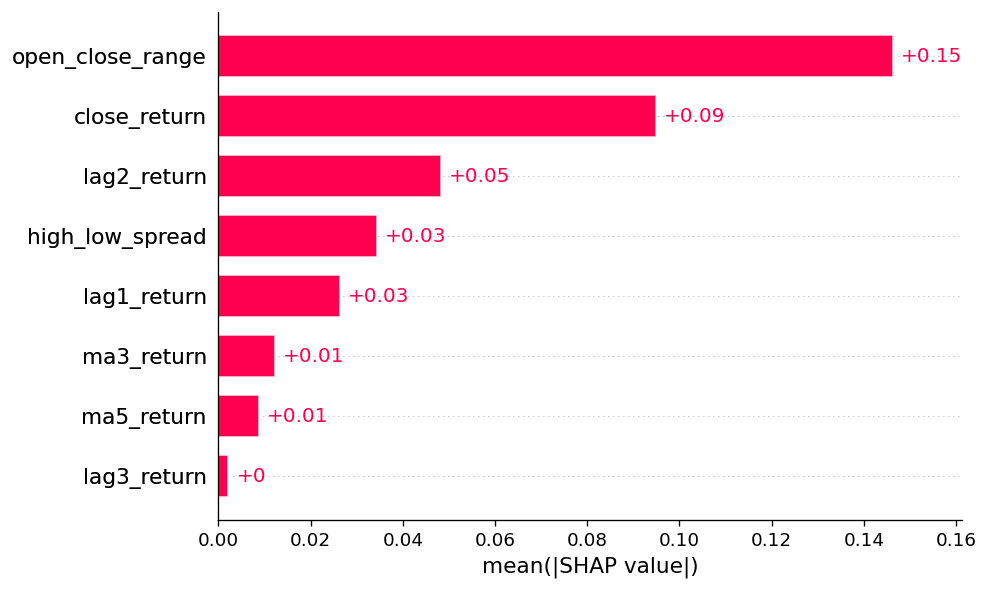

<Figure size 768x576 with 0 Axes>

In [67]:
shap_exp.plot_bar()

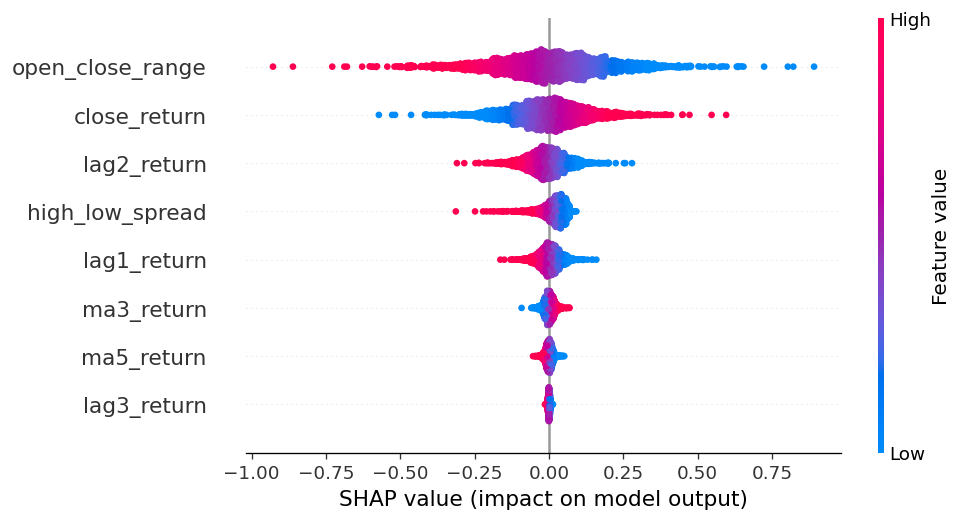

<Figure size 768x576 with 0 Axes>

In [68]:
shap_exp.plot_beeswarm()

Instance 0: predicted UP (prob=0.483)


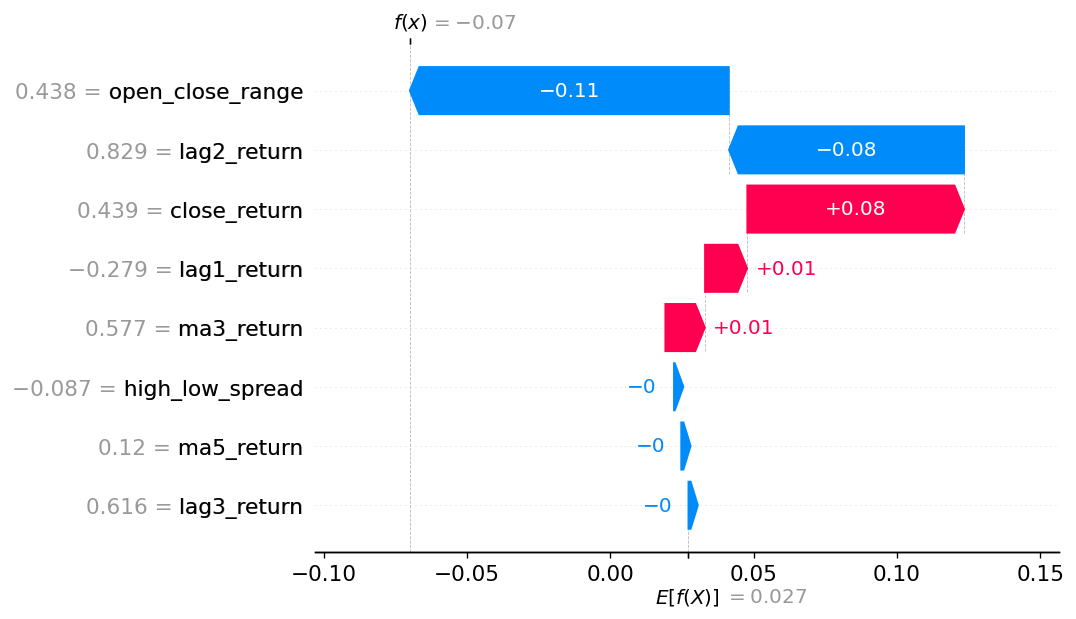

<Figure size 768x576 with 0 Axes>

Instance 1: predicted DOWN (prob=0.510)


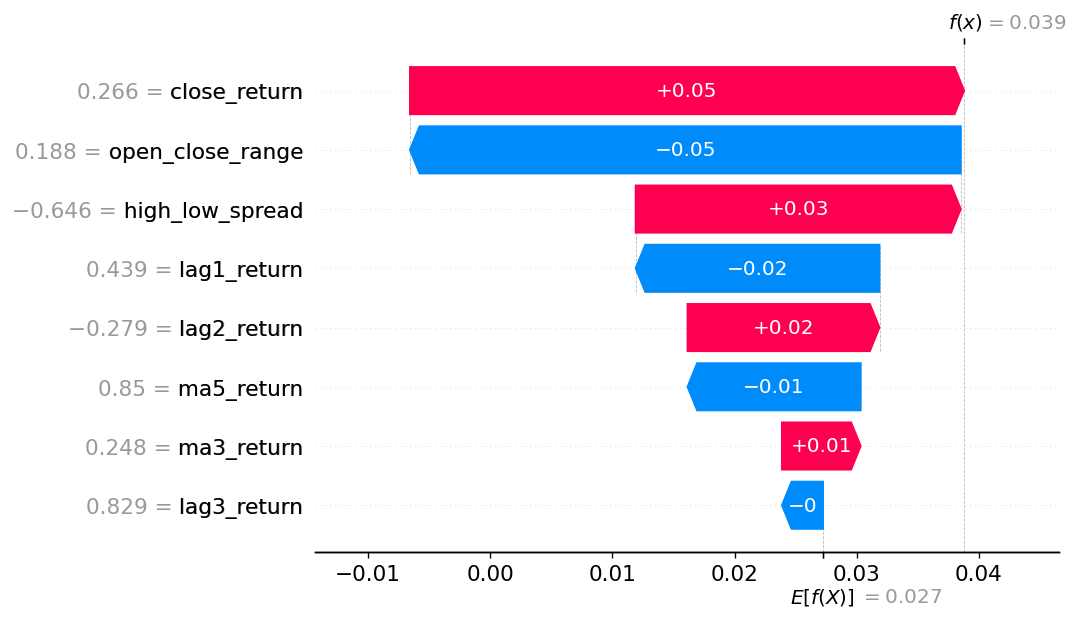

<Figure size 768x576 with 0 Axes>

In [69]:
y_test = direction_model.y_test
y_pred_proba = direction_model.y_pred_proba

up_idx = np.where(y_test == 1)[0][0]
down_idx = np.where(y_test == 0)[0][0]

shap_exp.plot_waterfall(up_idx, label='UP', probability=y_pred_proba[up_idx])
shap_exp.plot_waterfall(down_idx, label='DOWN', probability=y_pred_proba[down_idx])

---
## Permutation Feature Importance (PFI)

PFI measures how much the model's predictive performance drops when a single feature column is randomly shuffled, destroying its relationship with the target (Molnar, 2025). It is model-agnostic and directly measures the model's reliance on each feature.

We use AUC-ROC (not accuracy) because the direction target is close to 50/50 but not perfectly balanced. We run 30 permutation repeats per feature to estimate the mean and standard deviation of each importance score. The std captures the **stochasticity** inherent in PFI, which is relevant for the robustness analysis.

In [70]:
pfi_exp = PFIExplainer(feature_names=EURUSDDataset.FEATURES, n_repeats=30)
pfi_exp.explain(direction_model.classifier, direction_model.X_test_scaled, direction_model.y_test)

PFI global feature importance (mean AUC drop, 30 repeats):
open_close_range    0.009066
close_return        0.004228
lag1_return         0.003460
lag2_return         0.001030
ma3_return         -0.000348
lag3_return        -0.000364
ma5_return         -0.000671
high_low_spread    -0.001778


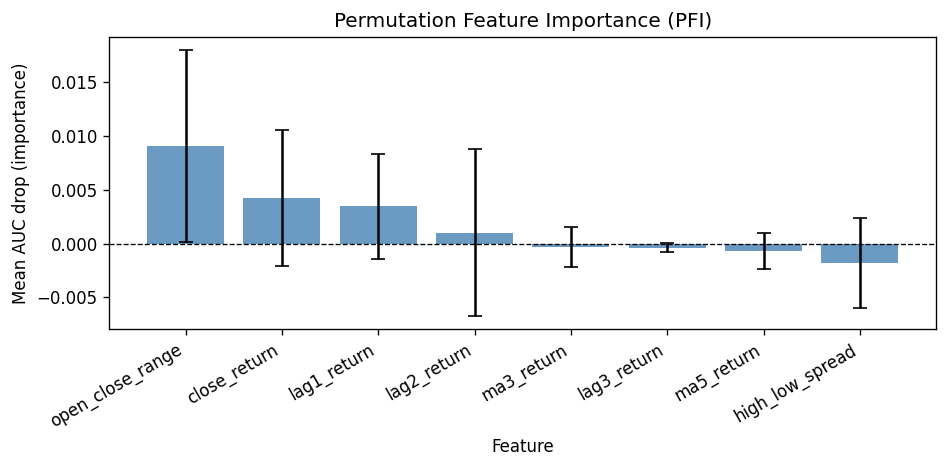

In [71]:
pfi_exp.plot()

---
## Feature Ablation

Feature Ablation is described in Captum (2024). It measures a feature's importance by **replacing it with a neutral baseline value**, here the training mean of that feature after standardisation (i.e., 0, since the data is standardised), and observing how much the model's predictive performance changes.

**Key difference from PFI:** PFI shuffles the feature, breaking its statistical association with the target but preserving its marginal distribution. Feature Ablation replaces the feature with a constant, which directly tests the model's *functional dependency* on that feature. The question is not "what if this feature were random" but "what if this feature were completely uninformative (at its mean)".

In [72]:
ablation_exp = FeatureAblation(feature_names=EURUSDDataset.FEATURES)
ablation_exp.explain(direction_model.classifier, direction_model.X_test_scaled, direction_model.y_test)

Baseline AUC: 0.5116

Feature Ablation importance:
open_close_range    0.007388
lag1_return         0.005374
close_return        0.001714
lag3_return        -0.000290
ma5_return         -0.000483
ma3_return         -0.000625
lag2_return        -0.001734
high_low_spread    -0.004605


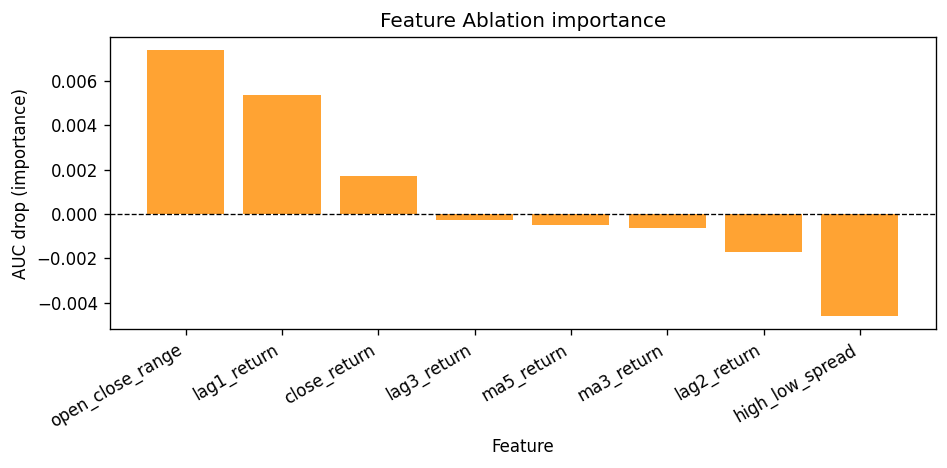

In [73]:
ablation_exp.plot()

---
## Consistency Analysis

To evaluate **consistency**, we compare the feature importance rankings produced by all three methods using the **Spearman rank correlation** $\rho$. Spearman's $\rho$ measures the monotonic agreement between two rankings:

- $\rho = 1.0$: perfect agreement
- $\rho > 0.7$: strong consistency
- $\rho < 0.5$: methods disagree substantially

A high Spearman $\rho$ across all three pairs means that, regardless of which method a practitioner uses, they would reach the same conclusion about which features drive the model.

In [74]:
consistency = ConsistencyAnalyzer(feature_names=EURUSDDataset.FEATURES)
consistency.analyze(shap_exp.importance, pfi_exp.importance_mean, ablation_exp.scores)

Spearman rank correlation matrix (consistency):
                   SHAP    PFI  Feature Ablation
SHAP              1.000  0.690             0.262
PFI               0.690  1.000             0.762
Feature Ablation  0.262  0.762             1.000


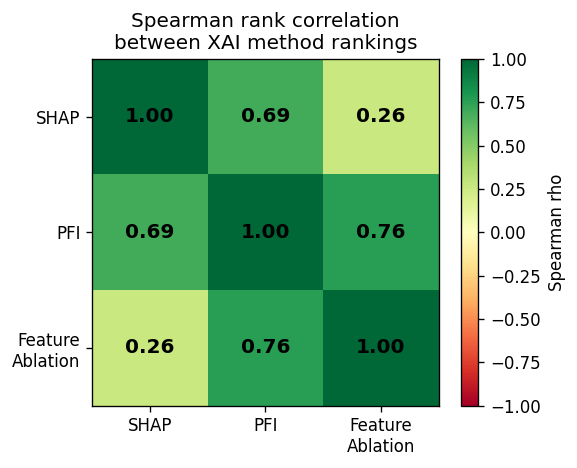

In [75]:
consistency.plot_heatmap()

In [76]:
consistency.print_ranking_table()

Feature rankings by method (1 = most important):
                  SHAP rank  PFI rank  Ablation rank
open_close_range          1         1              1
close_return              2         2              3
lag2_return               3         4              7
high_low_spread           4         8              8
lag1_return               5         3              2
ma3_return                6         5              6
ma5_return                7         7              5
lag3_return               8         6              4


---
## Robustness Analysis

Robustness measures whether explanations remain stable when the input data is slightly perturbed - a critical property for a reliable decision-support tool in finance (Alvarez-Melis & Jaakkola, 2018).

We add Gaussian noise at five levels (1%, 5%, 10%, 20%, 50% of each feature's std), recompute SHAP and PFI rankings, and measure the Spearman rank correlation against the original clean rankings. This is repeated for 10 random seeds to estimate variance. A stable rho means the explanation method is robust to noisy inputs.

In [77]:
robustness = RobustnessAnalyzer(
    feature_names=EURUSDDataset.FEATURES,
    noise_levels=[0.01, 0.05, 0.1, 0.2, 0.5],
    n_seeds=10
)
robustness.run(
    classifier=direction_model.classifier,
    shap_exp=shap_exp,
    X_test_scaled=direction_model.X_test_scaled,
    y_test=direction_model.y_test,
    shap_importance=shap_exp.importance,
    pfi_importance_mean=pfi_exp.importance_mean
)

Robustness analysis complete.


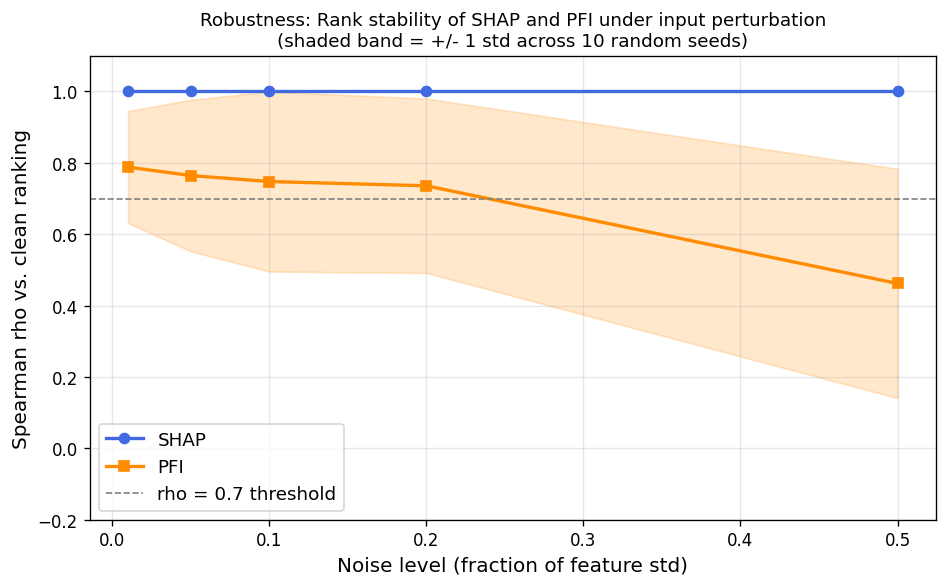


Robustness summary table:
 noise_frac  SHAP_rho_mean  SHAP_rho_std  PFI_rho_mean  PFI_rho_std
       0.01            1.0           0.0         0.788        0.157
       0.05            1.0           0.0         0.764        0.212
       0.10            1.0           0.0         0.748        0.252
       0.20            1.0           0.0         0.736        0.244
       0.50            1.0           0.0         0.462        0.321


In [78]:
robustness.plot()

In [79]:
robustness.check_ablation_robustness(
    classifier=direction_model.classifier,
    ablation_scores=ablation_exp.scores,
    X_test_scaled=direction_model.X_test_scaled,
    y_test=direction_model.y_test,
    noise_frac=0.1
)

Feature Ablation rank stability at noise_frac=0.1: Spearman rho = 0.976


## Summary of Results

This cell prints a concise summary of all key results for easy reference when writing the report.

In [80]:
print(f"Model: accuracy={direction_model.accuracy:.4f}  AUC={direction_model.auc:.4f}")
print(f"SHAP top-3: {list(shap_exp.ranking.index[:3])}")
print(f"PFI top-3: {list(pfi_exp.ranking.index[:3])}")
print(f"Ablation: {list(ablation_exp.ranking.index[:3])}")

noise_idx = robustness.noise_levels.index(0.1)
print(f"\nConsistency (Spearman rho):")
print(f"SHAP vs PFI = {consistency.corr_matrix.loc['SHAP', 'PFI']:.3f}")
print(f"SHAP vs Ablation = {consistency.corr_matrix.loc['SHAP', 'Feature Ablation']:.3f}")
print(f"PFI vs Ablation = {consistency.corr_matrix.loc['PFI', 'Feature Ablation']:.3f}")

print(f"\nRobustness at noise=0.1:")
print(f"SHAP rho = {robustness.shap_mean_rho[noise_idx]:.3f}")
print(f"PFI rho = {robustness.pfi_mean_rho[noise_idx]:.3f}")
print(f"FA rho = {robustness.ablation_rho:.3f}")

Model: accuracy=0.5164  AUC=0.5116
SHAP top-3: ['open_close_range', 'close_return', 'lag2_return']
PFI top-3: ['open_close_range', 'close_return', 'lag1_return']
Ablation: ['open_close_range', 'lag1_return', 'close_return']

Consistency (Spearman rho):
SHAP vs PFI = 0.690
SHAP vs Ablation = 0.262
PFI vs Ablation = 0.762

Robustness at noise=0.1:
SHAP rho = 1.000
PFI rho = 0.748
FA rho = 0.976
